<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/ESO003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# HES EOS + dynamic species toy universe

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "magma"


In [2]:
# Lattice size
N = 128

# Time stepping
dt = 0.01
n_steps = 2000
output_every = 200

# Environment parameters
env_ring_radius = 0.35
env_ring_width  = 0.05
env_basin_radius = 0.15
env_basin_depth  = -1.0
env_background_slope = 0.3

# Species parameters (will be used in registry)


In [4]:
# Normalized coordinates in [-1, 1] x [-1, 1]
x = np.linspace(-1.0, 1.0, N)
y = np.linspace(-1.0, 1.0, N)
X, Y = np.meshgrid(x, y, indexing="ij")

R = np.sqrt(X**2 + Y**2)


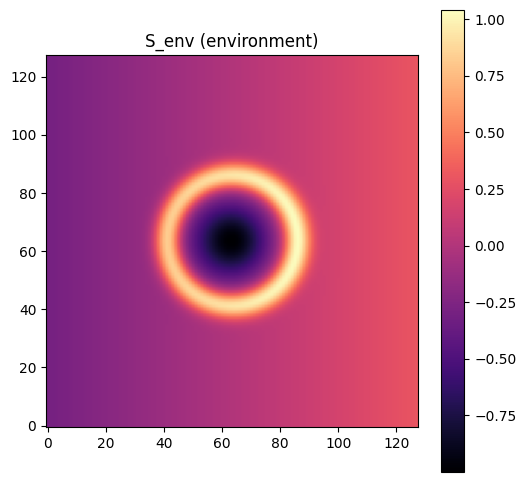

In [5]:
def build_environment(X, Y, R):
    # Outer ring (positive entropic ridge)
    ring = np.exp(-((R - env_ring_radius)**2) / (2 * env_ring_width**2))

    # Central basin (negative well)
    basin = env_basin_depth * np.exp(-(R**2) / (2 * env_basin_radius**2))

    # Background slope (e.g. gentle gradient in +x)
    background = env_background_slope * X

    S_env = ring + basin + background
    return S_env

S_env = build_environment(X, Y, R)

plt.imshow(S_env.T, origin="lower")
plt.title("S_env (environment)")
plt.colorbar()
plt.show()


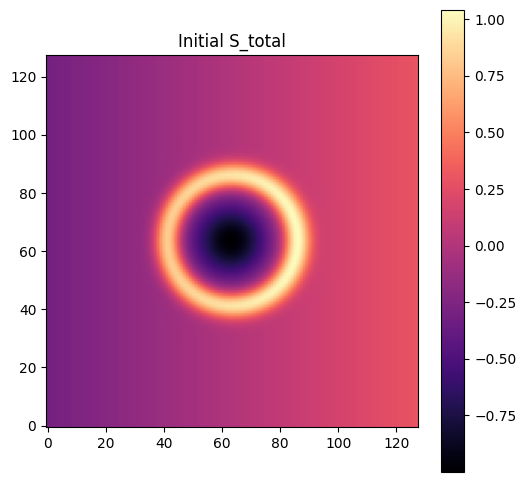

In [6]:
# Initialize dynamic entropic field
S_dyn = np.zeros_like(S_env)

def compute_S_total(S_env, S_dyn):
    return S_env + S_dyn

S_total = compute_S_total(S_env, S_dyn)

plt.imshow(S_total.T, origin="lower")
plt.title("Initial S_total")
plt.colorbar()
plt.show()


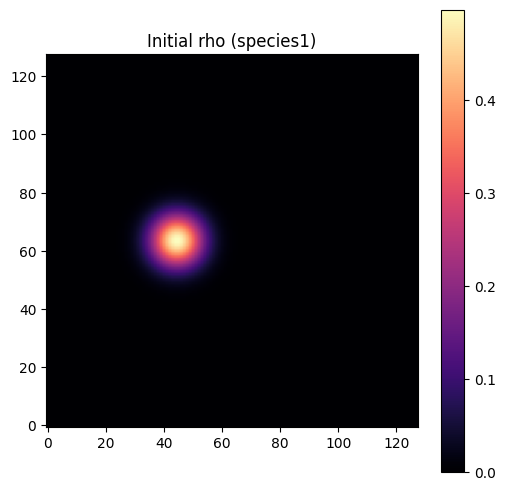

In [7]:
from dataclasses import dataclass

@dataclass
class Species:
    name: str
    mass: float
    gamma: float
    kappa: float
    coupling: float

# Example: two species
species_list = [
    Species("species1", mass=1.0, gamma=5/3, kappa=1.0, coupling=1.0),
    Species("species2", mass=0.5, gamma=4/3, kappa=0.5, coupling=0.8),
]

ns = len(species_list)

# Species fields: rho, vx, vy
rho = np.zeros((ns, N, N))
vx  = np.zeros((ns, N, N))
vy  = np.zeros((ns, N, N))

# Simple initial condition: small Gaussian blobs
def init_species(rho, X, Y):
    for s in range(ns):
        cx = -0.3 + 0.3 * s
        cy = 0.0
        blob = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * 0.1**2))
        rho[s] = 0.5 * blob
    return rho

rho = init_species(rho, X, Y)

plt.imshow(rho[0].T, origin="lower")
plt.title("Initial rho (species1)")
plt.colorbar()
plt.show()


In [8]:
def compute_pressure(rho, species_list):
    P = np.zeros_like(rho)
    for s, sp in enumerate(species_list):
        P[s] = sp.kappa * rho[s]**sp.gamma
    return P

def grad2d(field):
    # Simple central differences via np.gradient
    dfdx = np.gradient(field, axis=0)
    dfdy = np.gradient(field, axis=1)
    return dfdx, dfdy


In [9]:
def update_species(rho, vx, vy, S_total, species_list, dt):
    ns, nx, ny = rho.shape

    P = compute_pressure(rho, species_list)
    dSdx, dSdy = grad2d(S_total)

    for s, sp in enumerate(species_list):
        dPdx, dPdy = grad2d(P[s])

        # Momentum update: drift down ∇S_total + pressure forces
        vx[s] -= dt * (dSdx + dPdx / (rho[s] + 1e-8))
        vy[s] -= dt * (dSdy + dPdy / (rho[s] + 1e-8))

        # Continuity update: ∂t rho + ∇·(rho v) = 0
        flux_x = rho[s] * vx[s]
        flux_y = rho[s] * vy[s]

        dfluxdx = np.gradient(flux_x, axis=0)
        dfluxdy = np.gradient(flux_y, axis=1)

        rho[s] -= dt * (dfluxdx + dfluxdy)

        # Optional: clamp negatives
        rho[s] = np.clip(rho[s], 0.0, None)

    return rho, vx, vy, P


In [11]:
# Simple curvature-like feedback: species source modifies S_dyn

curvature_strength = 0.02
diffusion_coeff = 0.001
nonlinear_coeff = 0.0  # set >0 if you want nonlinear term

def laplacian(field):
    return (
        -4 * field
        + np.roll(field, 1, axis=0)
        + np.roll(field, -1, axis=0)
        + np.roll(field, 1, axis=1)
        + np.roll(field, -1, axis=1)
    )

def species_curvature_source(rho, P, species_list):
    src = np.zeros_like(rho[0])
    for s, sp in enumerate(species_list):
        src += sp.coupling * (rho[s] + P[s])
    return src

def update_S_dyn(S_dyn, S_env, rho, P, species_list, dt):
    S_total = compute_S_total(S_env, S_dyn)

    # Diffusion
    diff_term = diffusion_coeff * laplacian(S_dyn)

    # Nonlinear term (optional)
    nonlin_term = nonlinear_coeff * S_dyn**3

    # Species curvature source
    src = species_curvature_source(rho, P, species_list)

    dSdt = diff_term + nonlin_term + curvature_strength * src

    S_dyn = S_dyn + dt * dSdt
    return S_dyn


step 0/2000


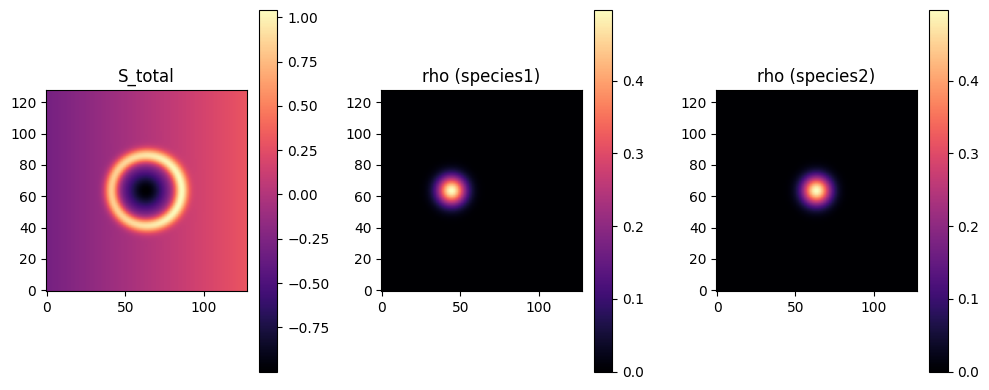

step 200/2000


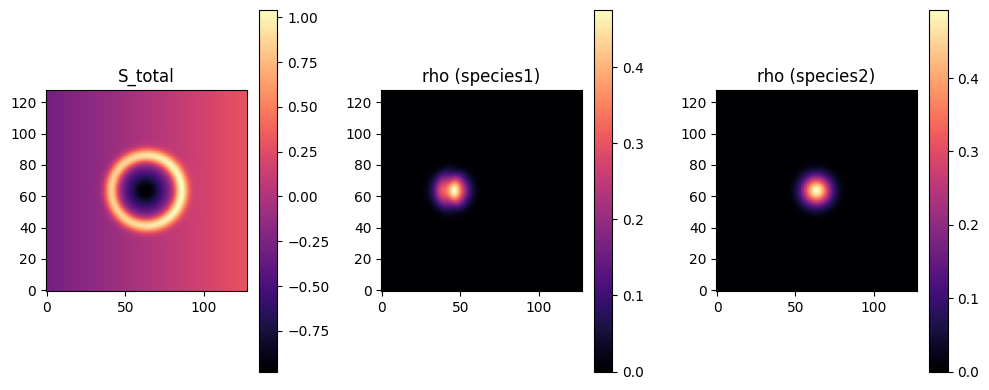

step 400/2000


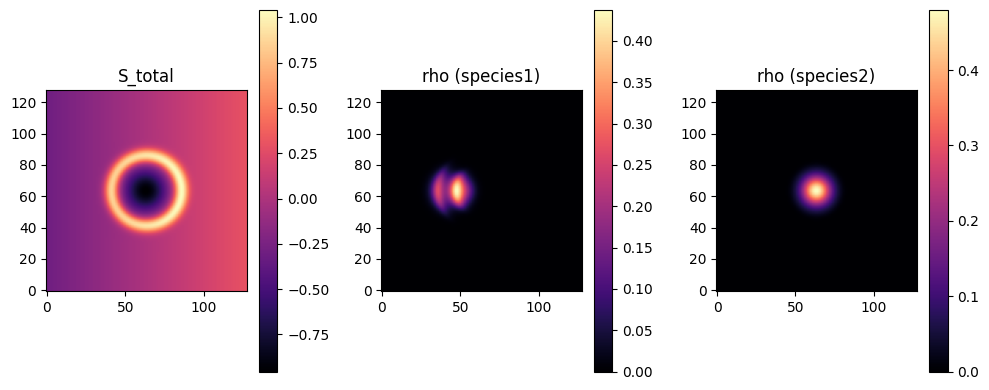

step 600/2000


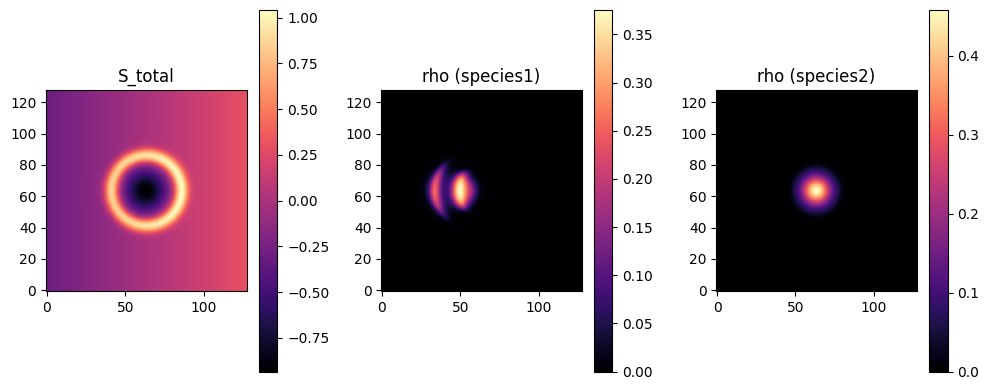

step 800/2000


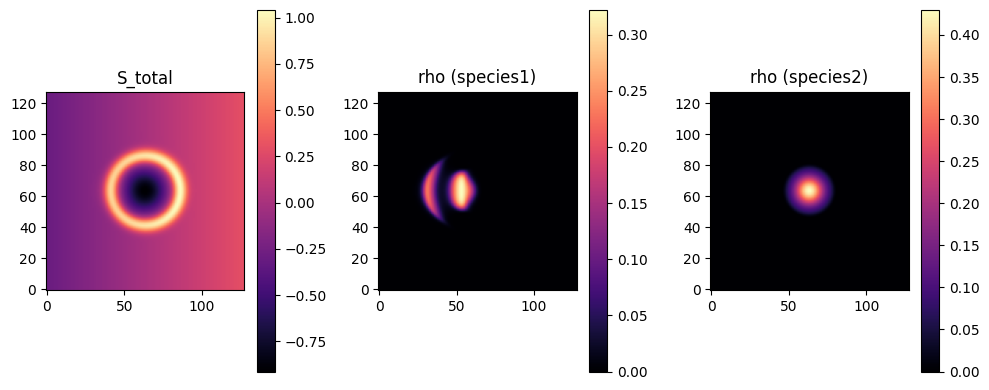

/tmp/ipykernel_3772/2215936036.py:29: RuntimeWarning: overflow encountered in power
  nonlin_term = nonlinear_coeff * S_dyn**3
/tmp/ipykernel_3772/2215936036.py:29: RuntimeWarning: invalid value encountered in multiply
  nonlin_term = nonlinear_coeff * S_dyn**3
/tmp/ipykernel_3772/563695186.py:4: RuntimeWarning: overflow encountered in power
  P[s] = sp.kappa * rho[s]**sp.gamma
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1241: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/tmp/ipykernel_3772/3641417600.py:15: RuntimeWarning: overflow encountered in multiply
  flux_x = rho[s] * vx[s]
/tmp/ipykernel_3772/3641417600.py:15: RuntimeWarning: invalid value encountered in multiply
  flux_x = rho[s] * vx[s]
/tmp/ipykernel_3772/3641417600.py:16: RuntimeWarning: overflow encountered in multiply
  flux_y = rho[s] * vy[s]
/tmp/ipykernel_3772/3641417600.py:16: RuntimeWarning: invalid valu

step 1000/2000


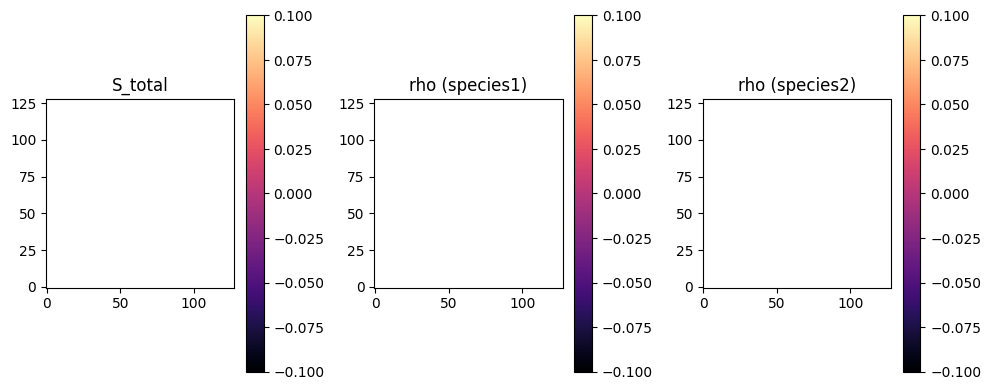

step 1200/2000


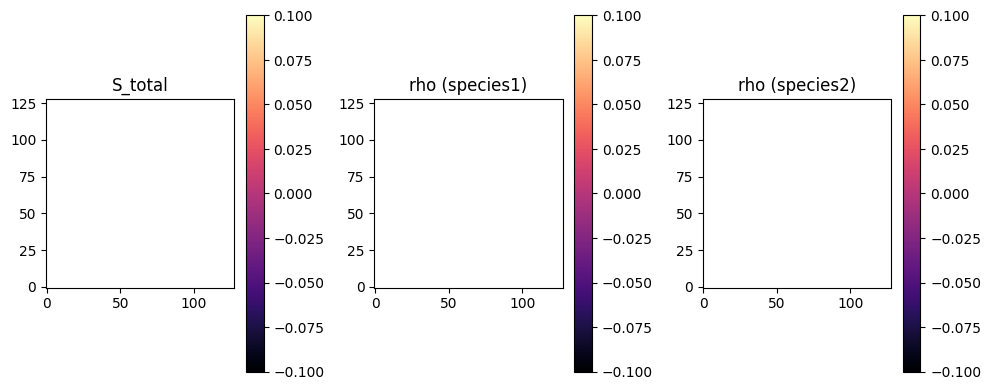

step 1400/2000


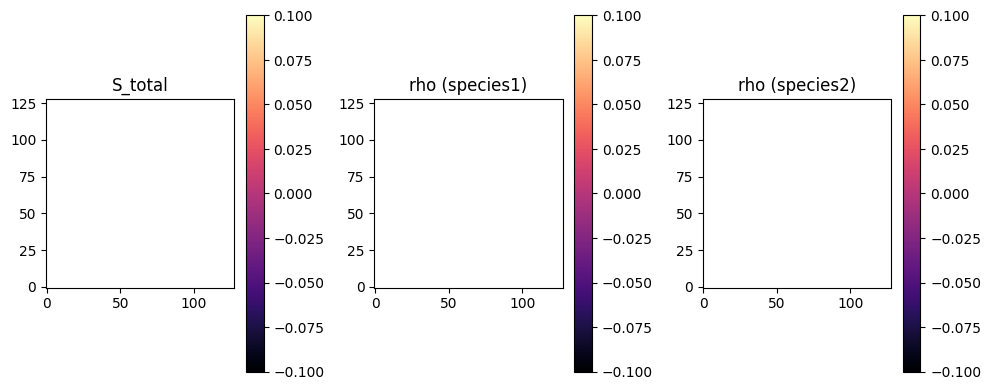

step 1600/2000


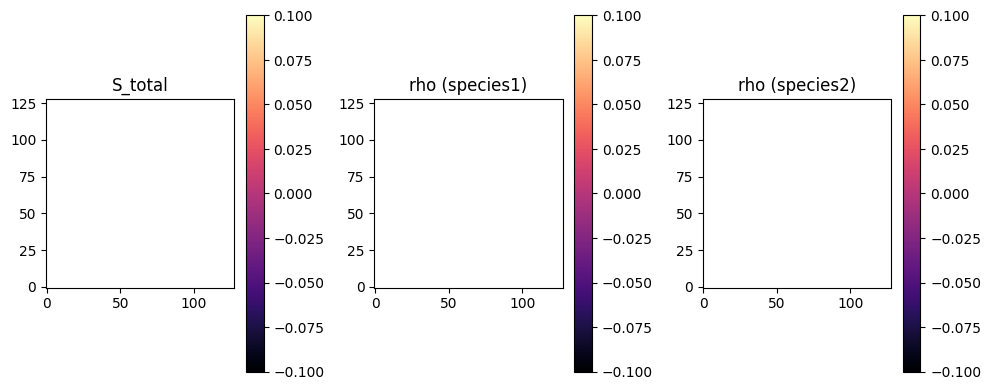

step 1800/2000


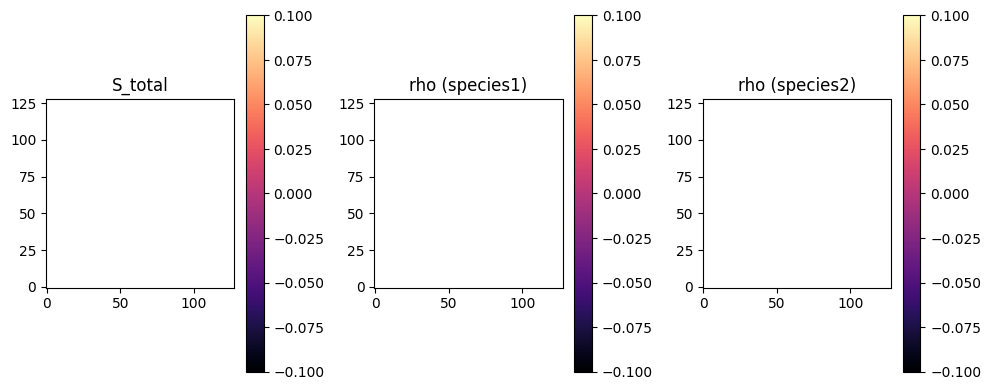

In [12]:
S_dyn = np.zeros_like(S_env)
S_total = compute_S_total(S_env, S_dyn)

for step in range(n_steps):
    # --- RK2: stage 1 ---
    rho1, vx1, vy1, P1 = update_species(rho.copy(), vx.copy(), vy.copy(),
                                        S_total, species_list, dt)
    S_dyn1 = update_S_dyn(S_dyn.copy(), S_env, rho1, P1, species_list, dt)
    S_total1 = compute_S_total(S_env, S_dyn1)

    # --- RK2: stage 2 ---
    rho2, vx2, vy2, P2 = update_species(rho.copy(), vx.copy(), vy.copy(),
                                        S_total1, species_list, dt)
    S_dyn2 = update_S_dyn(S_dyn.copy(), S_env, rho2, P2, species_list, dt)

    # Combine stages (Heun / RK2)
    rho = 0.5 * (rho1 + rho2)
    vx  = 0.5 * (vx1 + vx2)
    vy  = 0.5 * (vy1 + vy2)
    S_dyn = 0.5 * (S_dyn1 + S_dyn2)
    S_total = compute_S_total(S_env, S_dyn)

    if step % output_every == 0:
        print(f"step {step}/{n_steps}")
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(S_total.T, origin="lower")
        plt.title("S_total")
        plt.colorbar()

        plt.subplot(1, 3, 2)
        plt.imshow(rho[0].T, origin="lower")
        plt.title("rho (species1)")
        plt.colorbar()

        plt.subplot(1, 3, 3)
        plt.imshow(rho[1].T, origin="lower")
        plt.title("rho (species2)")
        plt.colorbar()

        plt.tight_layout()
        plt.show()
